# 📦 Notebook 01 — Superstore Discount & Pricing Leakage Analysis

---

## 🏢 Business Context

In retail, two of the most common yet overlooked sources of revenue loss are **discount abuse** and **pricing inconsistency**. Discount abuse occurs when sales teams apply excessive discounts that erode margins — often to meet short-term targets — without realising the transaction has become loss-making. Pricing inconsistency occurs when the same product is sold at significantly different unit prices across transactions, leaving recoverable revenue on the table.

This notebook investigates both leakage types using the **Sample Superstore dataset** — a widely used retail simulation dataset covering US-based transactions across Furniture, Office Supplies, and Technology categories.

---

## ❗ Business Problem Statement

> *"The organisation is experiencing margin erosion despite stable revenue growth. Internal suspicion points to uncontrolled discounting practices and inconsistent product pricing as contributing factors. There is currently no systematic framework to quantify how much revenue is being lost through these channels."*

**Core questions this notebook answers:**
1. How much revenue is being lost due to discounts that simultaneously exceed acceptable thresholds and generate losses?
2. Which product categories and sub-categories are the biggest contributors to discount-driven losses?
3. How much potential revenue is being left uncaptured due to transactions priced below the product's established fair-market price?
4. Which specific products show the highest pricing leakage exposure?

---

## 🎯 Objectives

| # | Objective | Type |
|---|---|---|
| 1 | Identify transactions where discounting has directly caused a loss | Leakage Detection |
| 2 | Quantify total discount abuse leakage in absolute dollar terms | Quantification |
| 3 | Break down discount leakage by Category, Sub-Category, and Region | Segmentation |
| 4 | Establish a per-product price benchmark using a robust statistical method | Benchmarking |
| 5 | Calculate pricing leakage as the gap between benchmark and actual price | Leakage Detection |
| 6 | Rank top products driving pricing leakage | Prioritisation |
| 7 | Export the enriched analytical table to SQLite for downstream consolidation | Data Engineering |

---

## 📂 Dataset

| Property | Detail |
|---|---|
| **Name** | Sample - Superstore |
| **Source** | Kaggle — [Superstore Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) |
| **Format** | CSV (latin-1 encoding) |
| **Size** | ~9,994 rows × 21 columns |
| **Geography** | United States |
| **Time Period** | 2014 – 2017 |
| **Key Columns** | `Order Date`, `Sales`, `Quantity`, `Discount`, `Profit`, `Product ID`, `Category`, `Sub-Category`, `Region` |

---

## 🔬 Methodology

```
RAW DATA
    │
    ▼
DATA AUDIT          → Check nulls, duplicates, datatypes
    │
    ▼
DATATYPE FIXING     → Convert dates, fix Postal Code dtype
    │
    ▼
FEATURE ENGINEERING → Unit Price, Profit Margin %, Discount %,
                       Loss Flag, High Discount Flag
    │
    ├──► DISCOUNT LEAKAGE
    │         │
    │         ▼
    │    Flag:   Discount % > 20 AND Profit < 0
    │    Amount: abs(Profit) for flagged rows
    │
    └──► PRICING LEAKAGE
              │
              ▼
         Benchmark: 90th percentile Unit Price per Product ID
         Formula:   (Benchmark Price − Actual Price) × Quantity
         Clip:      Negative values set to 0
    │
    ▼
AGGREGATION         → By Category, Sub-Category, Region, Product
    │
    ▼
VISUALISATION       → Bar charts for leakage distribution
    │
    ▼
SQLITE EXPORT       → Table: superstore_analysis
```

---

## 📏 Scope

**In Scope:**
- Transactions from the Superstore dataset only
- Two leakage types: Discount Abuse and Pricing Leakage
- Feature-level analysis (no predictive modelling in this notebook)

**Out of Scope:**
- Customer-level return behaviour (covered in Notebook 03)
- Cross-dataset comparisons (covered in Notebook 04)
- Time-series trend analysis
- External market price benchmarking

---

## 📤 Deliverables

| Deliverable | Description |
|---|---|
| `superstore_analysis` table | Enriched dataset stored in `revenue_leakage.db` |
| `Discount Abuse Amount` column | Per-transaction discount leakage flag and amount |
| `Pricing Leakage Amount` column | Per-transaction pricing gap vs 90th percentile benchmark |
| Category / Sub-Category aggregations | Leakage ranked by business segment |
| Visualisations | Bar charts for category and region-wise leakage |

---

## ⚠️ Assumptions & Limitations

| # | Assumption / Limitation |
|---|---|
| 1 | The 20% discount threshold is based on domain convention, not a statistically derived breakeven point |
| 2 | The 90th percentile price is used as the "fair" price benchmark — it is dataset-internal and does not reflect external market prices |
| 3 | All monetary values are in USD |
| 4 | Transactions where `Profit = 0` exactly are not flagged as losses |
| 5 | Pricing leakage is clipped at zero — transactions priced *above* the benchmark are not treated as negative leakage |

---

## 📋 Notebook Structure

1. Library Imports & Setup
2. Data Loading
3. Dataset Audit (Shape, Dtypes, Nulls, Duplicates)
4. Datatype Fixing
5. Feature Engineering
6. Discount Abuse Leakage Analysis
7. Pricing Leakage Analysis
8. Aggregation & Visualisation
9. SQLite Export

---

| | |
|---|---|
| **Author** | Abhiram |
| **Project** | Revenue Leakage Intelligence System |
| **Notebook** | 01 of 04 |
| **Dataset** | Sample Superstore (Kaggle) |
| **Output Table** | `superstore_analysis` → `revenue_leakage.db` |

In [1]:
# ==============================
# BASIC SETUP
# ==============================

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# ==============================
# DATA HANDLING
# ==============================

import pandas as pd
import numpy as np

# ==============================
# DATABASE
# ==============================

import sqlite3

# ==============================
# VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns


# Seaborn theme
sns.set_style("whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==============================
# LOAD DATASETS
# ==============================

# SUPERSTORE DATASET
superstore = pd.read_csv(
    "../Data/Raw_Data/Sample - Superstore.csv",
    encoding="latin1"
)

# OLIST DATASETS
orders = pd.read_csv("../Data/Raw_Data/olist_orders_dataset.csv")

items = pd.read_csv("../Data/Raw_Data/olist_order_items_dataset.csv")

payments = pd.read_csv("../Data/Raw_Data/olist_order_payments_dataset.csv")

# UCI RETAIL DATASET
uci = pd.read_csv(
    "../Data/Raw_Data/online_retail_II.csv",
    encoding="latin1"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [3]:
# ==============================
# QUICK DATASET CHECK
# ==============================

print("SUPERSTORE SHAPE :", superstore.shape)
print("ORDERS SHAPE     :", orders.shape)
print("ITEMS SHAPE      :", items.shape)
print("PAYMENTS SHAPE   :", payments.shape)
print("UCI SHAPE        :", uci.shape)

SUPERSTORE SHAPE : (9994, 21)
ORDERS SHAPE     : (99441, 8)
ITEMS SHAPE      : (112650, 7)
PAYMENTS SHAPE   : (103886, 5)
UCI SHAPE        : (1067371, 8)


In [4]:
# ==============================
# SUPERSTORE AUDIT
# ==============================

print("=" * 50)
print("SUPERSTORE DATASET")
print("=" * 50)

# Columns
print("\nCOLUMNS:\n")
print(superstore.columns)

# Datatypes
print("\nDATATYPES:\n")
print(superstore.dtypes)

# Null Values
print("\nNULL VALUES:\n")
print(superstore.isnull().sum())

# Duplicate Rows
print("\nDUPLICATE ROWS:\n")
print(superstore.duplicated().sum())

SUPERSTORE DATASET

COLUMNS:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

DATATYPES:

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

NULL VALUES:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        

In [5]:
# ==============================
# SUPERSTORE DATATYPE FIXING
# ==============================

# Convert dates to datetime
superstore["Order Date"] = pd.to_datetime(superstore["Order Date"])

superstore["Ship Date"] = pd.to_datetime(superstore["Ship Date"])

# Convert Postal Code to string
superstore["Postal Code"] = superstore["Postal Code"].astype(str)

print("Datatype conversion completed successfully.")

Datatype conversion completed successfully.


In [6]:

superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
superstore.groupby("Discount")["Profit"].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

In [8]:
# ==============================
# FEATURE ENGINEERING
# ==============================

# --------------------------------
# DELIVERY DAYS
# --------------------------------

superstore["Delivery Days"] = (
    superstore["Ship Date"] - superstore["Order Date"]
).dt.days


# --------------------------------
# PROFIT MARGIN %
# --------------------------------

superstore["Profit Margin %"] = (
    superstore["Profit"] / superstore["Sales"]
) * 100


# --------------------------------
# DISCOUNT %
# --------------------------------

superstore["Discount %"] = (
    superstore["Discount"] * 100
)


# --------------------------------
# LOSS FLAG
# --------------------------------

superstore["Loss Flag"] = np.where(
    superstore["Profit"] < 0,
    1,
    0
)


# --------------------------------
# HIGH DISCOUNT FLAG
# --------------------------------

superstore["High Discount Flag"] = np.where(
    superstore["Discount %"] > 20,
    1,
    0
)

print("Feature engineering completed successfully.")

Feature engineering completed successfully.


In [9]:
superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Delivery Days,Profit Margin %,Discount %,Loss Flag,High Discount Flag
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,16.00,0.0,0,0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,30.00,0.0,0,0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,47.00,0.0,0,0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-40.00,45.0,1,1
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,11.25,20.0,0,0


In [10]:
# ==============================
# DISCOUNT ABUSE LEAKAGE FLAG
# ==============================

superstore["Discount Abuse Flag"] = np.where(
    (superstore["High Discount Flag"] == 1) &
    (superstore["Loss Flag"] == 1),
    1,
    0
)

print("Discount abuse flag created successfully.")

Discount abuse flag created successfully.


In [11]:
# ==============================
# DISCOUNT ABUSE LEAKAGE AMOUNT
# ==============================

superstore["Discount Abuse Amount"] = np.where(
    superstore["Discount Abuse Flag"] == 1,
    abs(superstore["Profit"]),
    0
)

print("Leakage amount calculated successfully.")

Leakage amount calculated successfully.


In [12]:
# ==============================
# CHECK FLAGGED TRANSACTIONS
# ==============================

flagged_transactions = superstore[
    superstore["Discount Abuse Flag"] == 1
]

flagged_transactions.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Delivery Days,Profit Margin %,Discount %,Loss Flag,High Discount Flag,Discount Abuse Flag,Discount Abuse Amount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,7,-40.000000,45.0,1,1,1,383.0310
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,5,0.80,-123.8580,4,-180.000000,80.0,1,1,1,123.8580
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,3,0.80,-3.8160,4,-150.000000,80.0,1,1,1,3.8160
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,2,0.30,-1.0196,2,-1.428571,30.0,1,1,1,1.0196
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,7,0.50,-1665.0522,4,-54.000000,50.0,1,1,1,1665.0522


In [13]:
# ==============================
# TOTAL DISCOUNT ABUSE LEAKAGE
# ==============================

total_leakage = superstore[
    "Discount Abuse Amount"
].sum()

print(f"Total Discount Abuse Leakage: ${total_leakage:,.2f}")

Total Discount Abuse Leakage: $138,515.24


In [14]:
# ==============================
# CATEGORY-WISE LEAKAGE
# ==============================

category_leakage = (
    superstore
    .groupby("Category")["Discount Abuse Amount"]
    .sum()
    .reset_index()
    .sort_values(
        by="Discount Abuse Amount",
        ascending=False
    )
)

category_leakage

,Category,Discount Abuse Amount
0,Furniture,54540.6571
1,Office Supplies,47140.1376
2,Technology,36834.4482


In [15]:
# ==============================
# SUB-CATEGORY LEAKAGE
# ==============================

subcategory_leakage = (
    superstore
    .groupby("Sub-Category")["Discount Abuse Amount"]
    .sum()
    .reset_index()
    .sort_values(
        by="Discount Abuse Amount",
        ascending=False
    )
)

subcategory_leakage.head(10)

,Sub-Category,Discount Abuse Amount
3,Binders,38510.4964
16,Tables,30761.1238
11,Machines,30118.6682
4,Bookcases,11097.7614
1,Appliances,8629.6412
5,Chairs,6737.1167
13,Phones,6715.7800
9,Furnishings,5944.6552
0,Accessories,0.0000
8,Fasteners,0.0000


In [16]:
# ==============================
# REGION-WISE LEAKAGE
# ==============================

region_leakage = (
    superstore
    .groupby("Region")["Discount Abuse Amount"]
    .sum()
    .reset_index()
    .sort_values(
        by="Discount Abuse Amount",
        ascending=False
    )
)

region_leakage

,Region,Discount Abuse Amount
0,Central,52997.5245
1,East,44622.5444
2,South,24880.4818
3,West,16014.6922


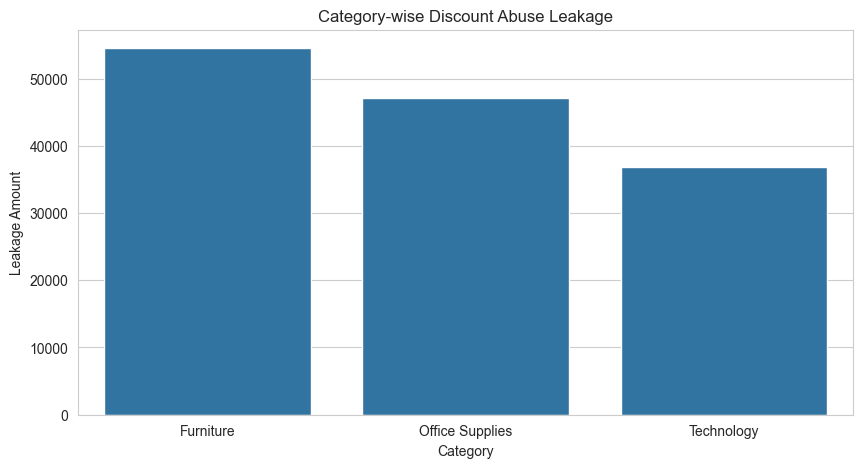

In [17]:
# ==============================
# CATEGORY LEAKAGE VISUALIZATION
# ==============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_leakage,
    x="Category",
    y="Discount Abuse Amount"
)

plt.title("Category-wise Discount Abuse Leakage")

plt.xlabel("Category")

plt.ylabel("Leakage Amount")

plt.show()

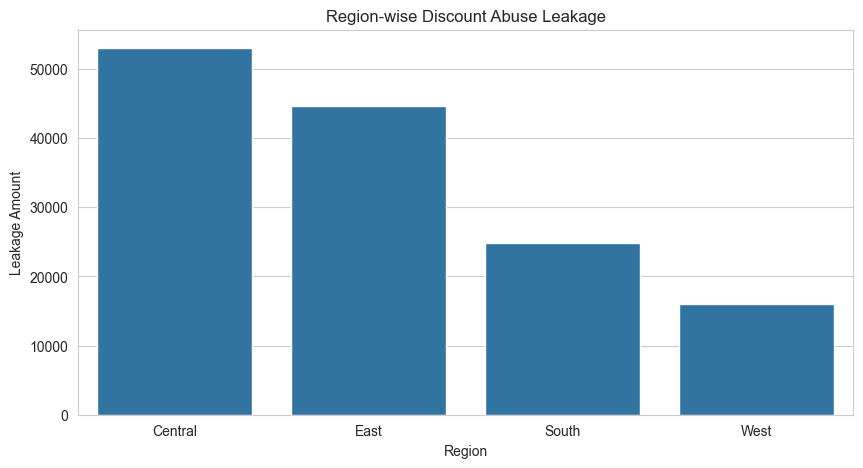

In [18]:
# ==============================
# REGION-WISE LEAKAGE VISUALIZATION
# ==============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=region_leakage,
    x="Region",
    y="Discount Abuse Amount"
)

plt.title("Region-wise Discount Abuse Leakage")

plt.xlabel("Region")

plt.ylabel("Leakage Amount")

plt.show()

In [19]:
# ==============================
# UNIT PRICE
# ==============================

superstore["Unit Price"] = (
    superstore["Sales"] / superstore["Quantity"]
)

print("Unit Price column created successfully.")

Unit Price column created successfully.


In [20]:
# ==============================
# STANDARD PRODUCT PRICE
# ==============================

product_price_reference = (
    superstore
    .groupby("Product ID")["Unit Price"]
    .max()
    .reset_index()
)

product_price_reference.rename(
    columns={
        "Unit Price": "Standard Unit Price"
    },
    inplace=True
)

product_price_reference.head()

,Product ID,Standard Unit Price
0,FUR-BO-10000112,91.686
1,FUR-BO-10000330,120.980
2,FUR-BO-10000362,170.980
3,FUR-BO-10000468,48.580
4,FUR-BO-10000711,70.980


In [21]:
# ==============================
# MERGE STANDARD PRICE
# ==============================

superstore = superstore.merge(
    product_price_reference,
    on="Product ID",
    how="left"
)

print("Standard price merged successfully.")

Standard price merged successfully.


In [22]:
# ==============================
# PRICING LEAKAGE AMOUNT
# ==============================

superstore["Pricing Leakage Amount"] = (
    (
        superstore["Standard Unit Price"]
        -
        superstore["Unit Price"]
    )
    *
    superstore["Quantity"]
)

# Negative leakage not possible
superstore["Pricing Leakage Amount"] = (
    superstore["Pricing Leakage Amount"]
    .clip(lower=0)
)

print("Pricing leakage calculated successfully.")

Pricing leakage calculated successfully.


In [23]:
# ==============================
# TOTAL PRICING LEAKAGE
# ==============================

total_pricing_leakage = (
    superstore["Pricing Leakage Amount"]
    .sum()
)

print(
    f"Total Potential Pricing Leakage: ${total_pricing_leakage:,.2f}"
)

Total Potential Pricing Leakage: $498,629.17


In [24]:
# ==============================
# TOP PRICING LEAKAGE RECORDS
# ==============================

superstore[
    [
        "Product Name",
        "Category",
        "Sales",
        "Quantity",
        "Unit Price",
        "Standard Unit Price",
        "Pricing Leakage Amount"
    ]
].sort_values(
    by="Pricing Leakage Amount",
    ascending=False
).head(10)

,Product Name,Category,Sales,Quantity,Unit Price,Standard Unit Price,Pricing Leakage Amount
9774,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.584,8,272.198,1360.990,8710.336
4991,Ibico EPK-21 Electric Binding System,Office Supplies,1889.990,5,377.998,1889.990,7559.960
7772,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,5,899.997,2399.992,7499.975
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1525.188,6,254.198,1270.990,6100.752
6425,Canon imageCLASS 2200 Advanced Copier,Technology,8399.976,4,2099.994,3499.990,5599.984
3011,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.985,5,509.997,1529.991,5099.970
1199,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,4,272.198,1360.990,4355.168
165,Lexmark MX611dhe Monochrome Laser Printer,Technology,8159.952,8,1019.994,1529.991,4079.976
2928,GBC DocuBind P400 Electric Binding System,Office Supplies,1633.188,4,408.297,1360.990,3810.772
7898,GBC DocuBind TL300 Electric Binding System,Office Supplies,1614.582,6,269.097,896.990,3767.358


In [25]:
# ==============================
# PRICING LEAKAGE DISTRIBUTION
# ==============================

superstore["Pricing Leakage Amount"].describe()

count    9.994000e+03
mean     4.989285e+01
std      2.541883e+02
min      0.000000e+00
25%      0.000000e+00
50%      2.842171e-14
75%      2.025300e+01
max      8.710336e+03
Name: Pricing Leakage Amount, dtype: float64

In [26]:
# ==============================
# REMOVE OLD PRICING COLUMNS
# ==============================

superstore.drop(
    columns=[
        "Standard Unit Price",
        "Pricing Leakage Amount"
    ],
    inplace=True
)

print("Old pricing benchmark removed.")


# ==============================
# 90TH PERCENTILE PRICE BENCHMARK
# ==============================

product_price_reference = (
    superstore
    .groupby("Product ID")["Unit Price"]
    .quantile(0.90)
    .reset_index()
)

product_price_reference.rename(
    columns={
        "Unit Price": "Standard Unit Price"
    },
    inplace=True
)

product_price_reference.head()


# ==============================
# MERGE NEW BENCHMARK
# ==============================

superstore = superstore.merge(
    product_price_reference,
    on="Product ID",
    how="left"
)

print("90th percentile benchmark merged.")

Old pricing benchmark removed.
90th percentile benchmark merged.


In [27]:
# ==============================
# RECALCULATE PRICING LEAKAGE
# ==============================

superstore["Pricing Leakage Amount"] = (
    (
        superstore["Standard Unit Price"]
        -
        superstore["Unit Price"]
    )
    *
    superstore["Quantity"]
)

superstore["Pricing Leakage Amount"] = (
    superstore["Pricing Leakage Amount"]
    .clip(lower=0)
)

print("Pricing leakage recalculated.")

Pricing leakage recalculated.


In [28]:
# ==============================
# NEW TOTAL PRICING LEAKAGE
# ==============================

total_pricing_leakage = (
    superstore["Pricing Leakage Amount"]
    .sum()
)

print(
    f"Updated Total Pricing Leakage: ${total_pricing_leakage:,.2f}"
)

Updated Total Pricing Leakage: $440,380.54


### Pricing Leakage Methodology

Pricing leakage was estimated by comparing the observed unit price
against the 90th percentile unit price for each product.

Why 90th percentile instead of maximum price?
Using maximum observed price created benchmark distortion due to
potential outlier transactions. The 90th percentile provides a more
stable and realistic premium pricing benchmark while reducing the
impact of extreme values.

Pricing Leakage Formula:
(Standard Unit Price - Actual Unit Price) × Quantity

In [29]:
# ==============================
# FINAL SUPERSTORE ANALYTICAL TABLE
# ==============================

superstore_final = superstore.copy()

# Remove unnecessary columns
superstore_final.drop(
    columns=["Row ID"],
    inplace=True
)

print("Final Superstore analytical table created.")

Final Superstore analytical table created.


In [30]:
# ==============================
# FINAL TABLE CHECK
# ==============================

print(superstore_final.shape)

superstore_final.head()

(9994, 30)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Delivery Days,Profit Margin %,Discount %,Loss Flag,High Discount Flag,Discount Abuse Flag,Discount Abuse Amount,Unit Price,Standard Unit Price,Pricing Leakage Amount
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,3,16.00,0.0,0,0,0,0.000,130.9800,125.0859,0.0000
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,3,30.00,0.0,0,0,0,0.000,243.9800,243.9800,0.0000
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,4,47.00,0.0,0,0,0,0.000,7.3100,7.3100,0.0000
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,7,-40.00,45.0,1,1,1,383.031,191.5155,348.2100,783.4725
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,7,11.25,20.0,0,0,0,0.000,11.1840,13.9800,5.5920


In [31]:
# ==============================
# SQLITE CONNECTION
# ==============================

conn = sqlite3.connect(
    "../Database/revenue_leakage.db"
)

print("Connected to SQLite.")

Connected to SQLite.


In [32]:
# ==============================
# STORE SUPERSTORE TABLE
# ==============================

superstore_final.to_sql(
    name="superstore_analysis",
    con=conn,
    if_exists="replace",
    index=False
)

print("Superstore table stored successfully.")

Superstore table stored successfully.


In [33]:
# ==============================
# VERIFY SQLITE TABLES
# ==============================

query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,uci_customer_return_analysis
1,olist_billing_analysis
2,superstore_analysis


In [34]:
# ==============================
# CLOSE CONNECTION
# ==============================

conn.close()

print("SQLite connection closed.")

SQLite connection closed.
